# QA and diffusion on a small planar graph

Build a reproducible planar graph with 30 vertices and average degree close to five, seed its most central vertex, and compare quantum-adjacency (QA) spreading with classical diffusion-kernel (DK) spreading through representative graph snapshots.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError(
        "Start Jupyter from the repository root or the notebooks directory."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import networkx as nx
import numpy as np
from scipy.sparse import csr_matrix
from scipy.spatial import Delaunay

from bioGraph.methods.ranking import dk_score, qa_score

## Planar toy graph

Well-separated random points are connected through a Delaunay triangulation. A Euclidean spanning tree guarantees connectivity, after which the shortest remaining Delaunay edges are added until the requested average degree is reached. Because only triangulation edges are used, the straight-edge drawing remains planar. The requested degree must lie between the spanning-tree minimum (just below 2) and the full triangulation maximum (typically between 5 and 6).

Graph: 30 vertices, 60 edges, average degree 4.00 (requested 4.00)
Central seed vertex: 16


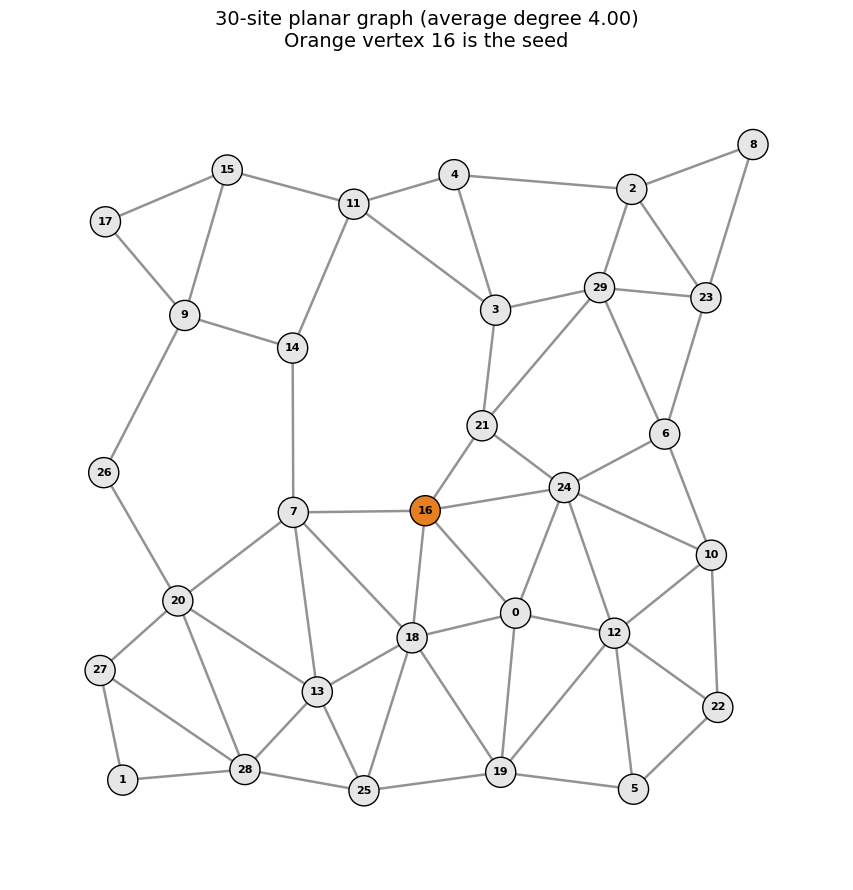

In [19]:
number_of_sites = 30
desired_average_degree = 4.0  # Change this parameter to control edge density.
minimum_point_distance = 0.14  # Increase for more visual separation.
random_seed = 0

rng = np.random.default_rng(random_seed)
points = []
maximum_sampling_attempts = 100_000
for _ in range(maximum_sampling_attempts):
    candidate = rng.uniform(0.04, 0.96, size=2)
    if all(np.linalg.norm(candidate - point) >= minimum_point_distance for point in points):
        points.append(candidate)
        if len(points) == number_of_sites:
            break
if len(points) != number_of_sites:
    raise RuntimeError(
        "Could not place all vertices. Reduce minimum_point_distance or the site count."
    )
points = np.asarray(points)
triangulation = Delaunay(points)

full_planar_graph = nx.Graph()
full_planar_graph.add_nodes_from(range(number_of_sites))
for triangle in triangulation.simplices:
    a, b, c = map(int, triangle)
    full_planar_graph.add_edges_from(((a, b), (b, c), (c, a)))
for left, right in full_planar_graph.edges():
    full_planar_graph.edges[left, right]["length"] = float(
        np.linalg.norm(points[left] - points[right])
    )

minimum_edges = number_of_sites - 1
maximum_edges = full_planar_graph.number_of_edges()
target_edges = int(round(number_of_sites * desired_average_degree / 2.0))
if not minimum_edges <= target_edges <= maximum_edges:
    minimum_degree = 2.0 * minimum_edges / number_of_sites
    maximum_degree = 2.0 * maximum_edges / number_of_sites
    raise ValueError(
        f"desired_average_degree must be between {minimum_degree:.2f} and "
        f"{maximum_degree:.2f} for this planar point set."
    )

graph = nx.minimum_spanning_tree(full_planar_graph, weight="length")
remaining_edges = sorted(
    (
        (attributes["length"], left, right)
        for left, right, attributes in full_planar_graph.edges(data=True)
        if not graph.has_edge(left, right)
    )
)
for length, left, right in remaining_edges:
    if graph.number_of_edges() >= target_edges:
        break
    graph.add_edge(left, right, length=length)

positions = {site: points[site] for site in graph.nodes()}
geometric_center = points.mean(axis=0)
seed_site = int(np.argmin(np.linalg.norm(points - geometric_center, axis=1)))
average_degree = 2.0 * graph.number_of_edges() / graph.number_of_nodes()

print(
    f"Graph: {graph.number_of_nodes()} vertices, {graph.number_of_edges()} edges, "
    f"average degree {average_degree:.2f} (requested {desired_average_degree:.2f})"
)
print(f"Central seed vertex: {seed_site}")
assert nx.is_connected(graph)

fig, ax = plt.subplots(figsize=(10, 9))
nx.draw_networkx_edges(
    graph, positions, ax=ax, edge_color="#777777", width=1.8, alpha=0.8
)
nx.draw_networkx_nodes(
    graph,
    positions,
    ax=ax,
    node_color=["#E67E22" if node == seed_site else "#E6E6E6" for node in graph],
    node_size=470,
    edgecolors="black",
    linewidths=1.0,
)
nx.draw_networkx_labels(graph, positions, ax=ax, font_size=8, font_weight="bold")
ax.set_title(
    f"{number_of_sites}-site planar graph (average degree {average_degree:.2f})\n"
    f"Orange vertex {seed_site} is the seed",
    fontsize=14,
)
ax.set_aspect("equal")
ax.margins(0.08)
ax.axis("off")
plt.tight_layout()
plt.show()

In [27]:
nodelist = sorted(graph.nodes())
adjacency = csr_matrix(nx.to_numpy_array(graph, nodelist=nodelist, dtype=float))
laplacian = csr_matrix(nx.laplacian_matrix(graph, nodelist=nodelist))
snapshot_times = [0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1.05, 1.2, 1.35, 1.5]

qa_densities = {
    time: qa_score(
        graph,
        [seed_site],
        t=time,
        H=-adjacency.copy(),
        nodelist=nodelist,
    )
    for time in snapshot_times
}
dk_densities = {
    time: dk_score(
        graph,
        [seed_site],
        t=time,
        L=laplacian,
        nodelist=nodelist,
    )
    for time in snapshot_times
}

print("QA density sums:", {t: round(float(v.sum()), 10) for t, v in qa_densities.items()})
print("DK density sums:", {t: round(float(v.sum()), 10) for t, v in dk_densities.items()})

QA density sums: {0.0: 1.0, 0.15: 1.0, 0.3: 1.0, 0.45: 1.0, 0.6: 1.0, 0.75: 1.0, 0.9: 1.0, 1.05: 1.0, 1.2: 1.0, 1.35: 1.0, 1.5: 1.0}
DK density sums: {0.0: 1.0, 0.15: 1.0, 0.3: 1.0, 0.45: 1.0, 0.6: 1.0, 0.75: 1.0, 0.9: 1.0, 1.05: 1.0, 1.2: 1.0, 1.35: 1.0, 1.5: 1.0}


## Density snapshots

Darker vertices have higher density. Both rows use the same nonlinear grayscale normalization from zero to one: this preserves absolute density comparisons while making low-density spreading visible. The seed has an orange outline.

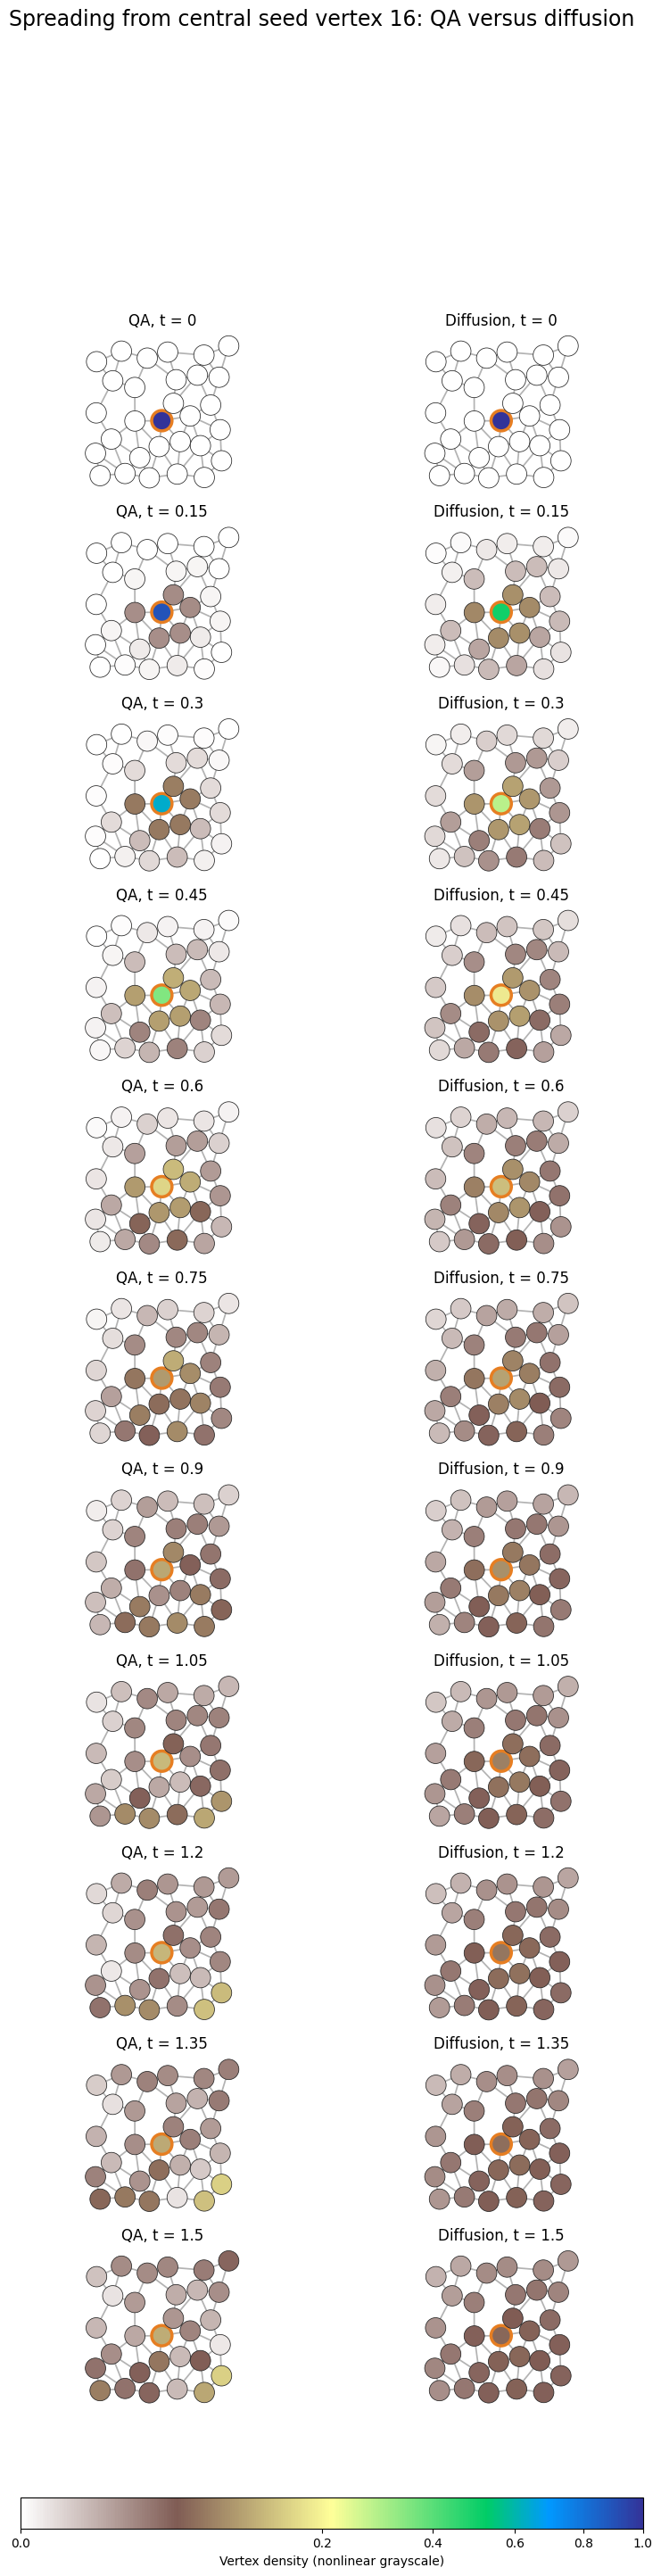

In [28]:
fig, axes = plt.subplots(
    len(snapshot_times), 2, figsize=(9, 3 * len(snapshot_times))
)
density_norm = PowerNorm(gamma=0.45, vmin=0.0, vmax=1.0)
density_mappable = plt.cm.ScalarMappable(norm=density_norm, cmap="terrain_r")
density_mappable.set_array([])

for row, time in enumerate(snapshot_times):
    for column, (method_name, density) in enumerate(
        (("QA", qa_densities[time]), ("Diffusion", dk_densities[time]))
    ):
        ax = axes[row, column]
        nx.draw_networkx_edges(
            graph,
            positions,
            ax=ax,
            edge_color="#8A8A8A",
            width=1.25,
            alpha=0.65,
        )
        node_colors = density_mappable.to_rgba(density)
        #plt.cm.terrain(density_norm(density))
        nx.draw_networkx_nodes(
            graph,
            positions,
            ax=ax,
            node_color=node_colors,
            node_size=270,
            edgecolors=["#E67E22" if node == seed_site else "#222222" for node in graph],
            linewidths=[2.5 if node == seed_site else 0.55 for node in graph],
        )
        ax.set_title(f"{method_name}, t = {time:g}", fontsize=12)
        ax.set_aspect("equal")
        ax.axis("off")

fig.colorbar(
    density_mappable,
    ax=axes,
    orientation="horizontal",
    fraction=0.045,
    pad=0.04,
    label="Vertex density (nonlinear grayscale)",
)
fig.suptitle(
    f"Spreading from central seed vertex {seed_site}: QA versus diffusion",
    fontsize=17,
    y=0.99,
)
plt.show()